In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/terrywww/ambdataset/AmbDataset.csv


In [2]:
import os;
os.listdir('/kaggle/input/')
df = pd.read_csv('/kaggle/input/datasets/terrywww/ambdataset/AmbDataset.csv')

In [3]:
# Inspect data
print(df.head())
print(df.columns)
print(df.shape)
print(df.info())

         inc_no inc_type                toc  TOC_DATE TOC_TIME  \
0  A25010100009      EMA  1.1.2025 00:07:15  1.1.2025  0:07:15   
1  A25010100015    HT-SK  1.1.2025 00:09:56  1.1.2025  0:09:56   
2  A25010100017      EMA  1.1.2025 00:10:04  1.1.2025  0:10:04   
3  A25010100039    EMAFR  1.1.2025 00:26:57  1.1.2025  0:26:57   
4  A25010100046      EMA  1.1.2025 00:29:30  1.1.2025  0:29:30   

  'PRM_TGMS_AMB_DEPOT'[Division] depot Div_for_loccode SubDiv_for_loccode  \
0                     K/W&Lantau   CHE      K/W&Lantau                K/W   
1                     K/W&Lantau   YAU      K/W&Lantau                K/W   
2                     K/W&Lantau   MON      K/W&Lantau                K/W   
3                          K/C&E   HOM      K/W&Lantau                K/W   
4                     K/W&Lantau   YAU      K/W&Lantau                K/W   

  loccode  ... completed_Call met_RTP conveycode COUNT_RTP  EUR  \
0    LCK1  ...              Y       Y        E10         Y    E   
1    Y

In [4]:
time_cols = ['toc', 'cti_time', 'res_time', 'ara_time', 'e99_time', 'arh_time', 'avm_time']
for col in time_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], 
                                 format='%d.%m.%Y %H:%M:%S',  
                                 errors='coerce')               

# Check after changing
print(df[time_cols].dtypes)        # should be datetime64[ns]
print(df['toc'].head())       

toc         datetime64[ns]
cti_time    datetime64[ns]
res_time    datetime64[ns]
ara_time    datetime64[ns]
e99_time    datetime64[ns]
arh_time    datetime64[ns]
avm_time    datetime64[ns]
dtype: object
0   2025-01-01 00:07:15
1   2025-01-01 00:09:56
2   2025-01-01 00:10:04
3   2025-01-01 00:26:57
4   2025-01-01 00:29:30
Name: toc, dtype: datetime64[ns]


In [5]:
df = df[df['toc'] <= df['ara_time']]

In [6]:
# data cleaning

df = df.drop_duplicates(subset=['toc', 'loccode', 'inc_type'], keep='first')

exclude_types = ['HT-SK', '1', '2D', 'U', 'SS', '2', 'MOUNTRES', '2C', '2A', 'RF', 'TREE', 'VESSELSS', 'HANG', '1EXP', 'EMA1-SK', 'VF', '2VESSEL', 'SEWER', 'EMAB', 'FLOOD', 'VESSELSSH', 'BOMBINT', 'VESSELSSC', 'EF', '2DEXP', 'DCIDC', 'R', 'RISKF'] 
df_clean = df[~df['inc_type'].str.contains('|'.join(exclude_types), case=False, na=False)]

df_clean['ResponseTimeMin'] = (df_clean['ara_time'] - df_clean['toc']).dt.total_seconds() / 60
df_clean = df_clean[(df_clean['ResponseTimeMin'] >= 0) & (df_clean['ResponseTimeMin'] <= 60)]

df_clean['Hour'] = df_clean['toc'].dt.hour
df_clean['DayOfWeek'] = df_clean['toc'].dt.day_name()
df_clean['IsRushHour'] = df_clean['Hour'].between(7,9) | df_clean['Hour'].between(17,19)
df_clean['TravelToHospitalMin'] = (df_clean['arh_time'] - df_clean['e99_time']).dt.total_seconds() / 60

df_clean.to_csv('cleaned_ambulance_2025.csv', index=False)
print(f"after cleaning there {len(df_clean):,} cases")
print(df_clean[['toc', 'arh_time', 'ResponseTimeMin']].head())

/tmp/ipykernel_16/3103819416.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['ResponseTimeMin'] = (df_clean['ara_time'] - df_clean['toc']).dt.total_seconds() / 60


after cleaning there 76,831 cases
                  toc            arh_time  ResponseTimeMin
0 2025-01-01 00:07:15 2025-01-01 00:39:19         8.983333
2 2025-01-01 00:10:04 2025-01-01 00:53:04         6.066667
4 2025-01-01 00:29:30 2025-01-01 01:26:49        14.416667
5 2025-01-01 00:31:19 2025-01-01 01:12:33        15.050000
7 2025-01-01 00:36:02                 NaT        52.150000


Overall: 96.5% | TTG: 93.9%
area        CSW        LCK        MKK        SKM        TST        TTG  \
Hour                                                                     
0     94.366197  96.341463  96.741344  93.103448  94.067797  92.708333   
1     96.307692  95.689655  98.245614  95.906433  94.387755  91.780822   
2     97.818182  97.457627  99.009901  96.835443  96.794872  98.214286   
3     98.106061  98.333333  98.520710  99.099099  99.378882  98.611111   
4     98.561151  96.470588  99.408284  98.611111  97.761194  97.142857   
5     99.068323  98.230088  99.449036  98.484848  98.518519  98.148148   
6     98.879552  97.902098  98.522167  98.984772  98.089172  96.875000   
7     97.448980  92.857143  98.026316  97.280967  99.090909  97.142857   
8     98.366834  95.294118  98.314015  98.654709  98.130841  94.495413   
9     98.063201  97.506234  98.059150  98.214286  97.229917  92.805755   
10    97.391304  98.328691  97.130802  96.050269  94.306931  89.830508   
11    96.4

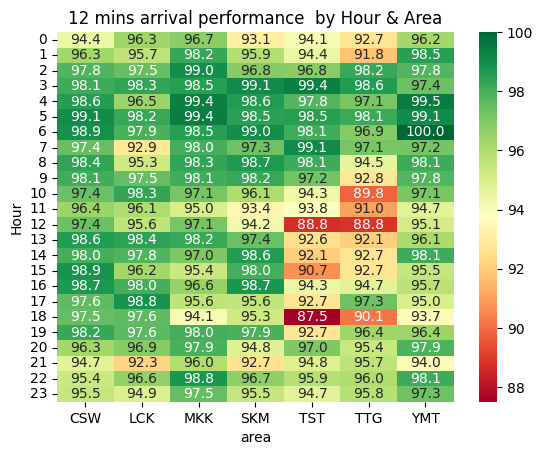

    Hour inc_type  OnTimeRate  CallVolume
63    14   LOCKIN    0.000000           1
33     8     EMAT   62.500000           8
8      2     EMAT   66.666667           3
41    10     EMAT   83.333333           6
25     6     EMAT   85.714286           7
37     9     EMAT   87.500000           8
50    12      EMA   87.681159         138
76    18      EMA   88.181818         110
2      0     EMAT   88.888889           9
40    10      EMA   89.814815         108


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only TTG + overall
df_ttg = df_clean[df_clean['area'] == 'TTG']

# 1. overall vs TTG 
overall_ontime = (df_clean['ResponseTimeMin'] <= 12).mean() * 100
ttg_ontime = (df_ttg['ResponseTimeMin'] <= 12).mean() * 100
print(f"Overall: {overall_ontime:.1f}% | TTG: {ttg_ontime:.1f}%")

# 2. （rush hour / hour）
pivot = pd.pivot_table(df_clean, 
                       values='ResponseTimeMin', 
                       index='Hour', 
                       columns='area', 
                       aggfunc=lambda x: (x <= 12).mean() * 100)
print(pivot)  

# 3. （Heatmap + Bar）
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('12 mins arrival performance  by Hour & Area')
plt.show()

# 4. root cause
cause = df_ttg.groupby(['Hour', 'inc_type']).agg(
    OnTimeRate=('ResponseTimeMin', lambda x: (x<=12).mean()*100),
    CallVolume=('ResponseTimeMin', 'count')
).reset_index()
print(cause.sort_values('OnTimeRate').head(10))

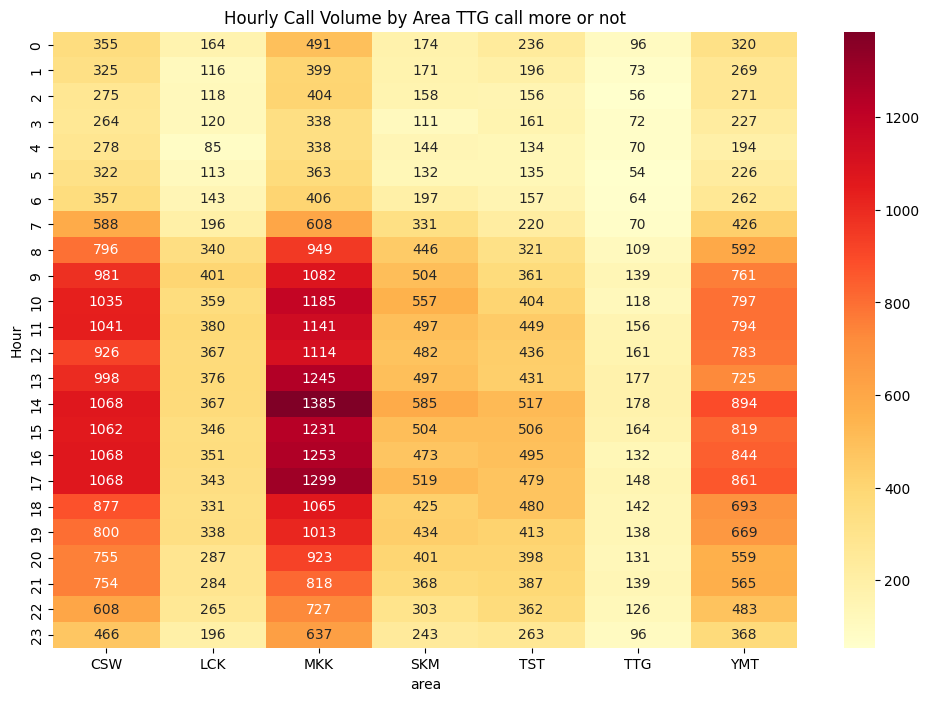

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_volume = pd.pivot_table(df_clean, 
                              values='ResponseTimeMin',   # 其實計count就得
                              index='Hour', 
                              columns='area', 
                              aggfunc='count')   # 改成count = 呼叫量

plt.figure(figsize=(12,8))
sns.heatmap(pivot_volume, annot=True, fmt='d', cmap='YlOrRd')  # 紅色 = call多
plt.title('Hourly Call Volume by Area TTG call more or not')
plt.ylabel('Hour')
plt.xlabel('area')
plt.show()

        OnTimeRate  AvgResponse  CallVolume
Is_TTG                                     
False        96.65         7.58       74022
True         93.88         7.71        2809


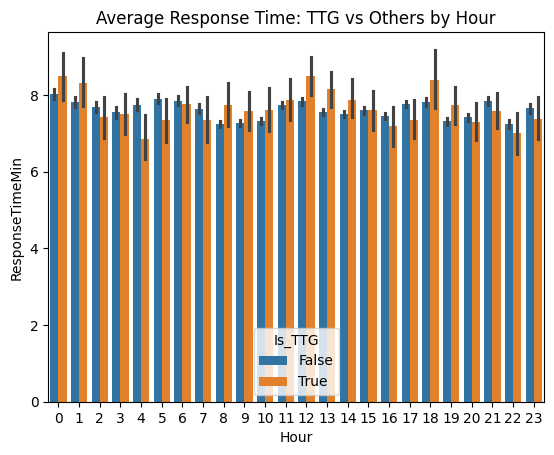

               OnTimeRate  CallCount  AvgResponse
Hour inc_type                                    
14   LOCKIN          0.00          1        13.68
8    EMAT           62.50          8         9.94
2    EMAT           66.67          3         8.67
10   EMAT           83.33          6         7.00
6    EMAT           85.71          7         8.33
9    EMAT           87.50          8         8.41
12   EMA            87.68        138         8.82
18   EMA            88.18        110         8.67
0    EMAT           88.89          9         8.09
10   EMA            89.81        108         7.75
15   EMAT           90.00         10         7.68
11   EMA            90.00        140         8.06
1    EMA            90.77         65         8.48
13   EMA            90.79        152         8.28
12   EMAT           90.91         11         6.31
               OnTimeRate  CallCount  AvgResponse
Hour inc_type                                    
14   LOCKIN          0.00          1        13.68


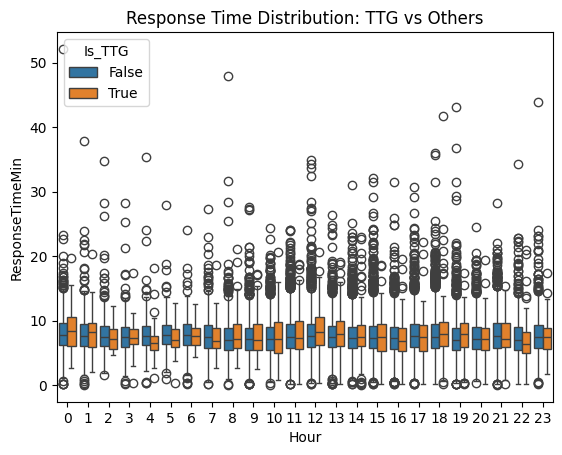

In [9]:
df_clean['Is_TTG'] = df_clean['area'] == 'TTG'

summary = df_clean.groupby('Is_TTG').agg(
    OnTimeRate=('ResponseTimeMin', lambda x: (x<=12).mean()*100),
    AvgResponse=('ResponseTimeMin', 'mean'),
    CallVolume=('ResponseTimeMin', 'count')
).round(2)

print(summary)

sns.barplot(data=df_clean, x='Hour', y='ResponseTimeMin', hue='Is_TTG')
plt.title('Average Response Time: TTG vs Others by Hour')
plt.show()



ttg_only = df_clean[df_clean['area'] == 'TTG']

# 按hour + incident type
worst = ttg_only.groupby(['Hour', 'inc_type']).agg(
    OnTimeRate=('ResponseTimeMin', lambda x: (x<=12).mean()*100),
    CallCount=('ResponseTimeMin', 'count'),
    AvgResponse=('ResponseTimeMin', 'mean')
).round(2)

print(worst.sort_values('OnTimeRate').head(15))

ttg_only = df_clean[df_clean['area'] == 'TTG']

# 按hour + incident type
worst = ttg_only.groupby(['Hour', 'inc_type']).agg(
    OnTimeRate=('ResponseTimeMin', lambda x: (x<=12).mean()*100),
    CallCount=('ResponseTimeMin', 'count'),
    AvgResponse=('ResponseTimeMin', 'mean')
).round(2)

print(worst.sort_values('OnTimeRate').head(15))

sns.boxplot(data=df_clean, x='Hour', y='ResponseTimeMin', hue='Is_TTG')
plt.title('Response Time Distribution: TTG vs Others')
plt.show()

In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# === 1. 先新建 OnTime 欄（binary）===
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)
df_clean['Is_TTG_num'] = df_clean['Is_TTG'].astype(int)  

# ======================
# A. 簡單統計檢定（T-test + Chi-square）
# ======================

# A1. T-test：TTG vs Others 平均 ResponseTimeMin 有冇分別？
ttg_resp = df_clean[df_clean['Is_TTG'] == True]['ResponseTimeMin']
others_resp = df_clean[df_clean['Is_TTG'] == False]['ResponseTimeMin']

t_stat, p_ttest = stats.ttest_ind(ttg_resp, others_resp, equal_var=False)  # Welch's t-test（穩陣）
print(f"=== T-test (Response Time) ===")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_ttest:.10f}")   # 通常會好細 <0.001

# A2. Chi-square test：TTG vs Others 達標率（OnTime）有冇分別？
contingency = pd.crosstab(df_clean['Is_TTG'], df_clean['OnTime'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\n=== Chi-square (OnTime Rate) ===")
print(f"Chi2 statistic: {chi2:.2f}")
print(f"p-value: {p_chi:.10f}")

# ======================
# B. 進階：Logistic Regression（多因素同時睇）
# ======================
# 將類別變數轉dummy
import statsmodels.formula.api as smf
import numpy as np

df_clean['Is_TTG_num'] = df_clean['Is_TTG'].astype(int)
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)

# 簡單版 Logistic Regression
logit_simple = smf.logit('OnTime ~ Is_TTG_num + Hour', data=df_clean).fit(disp=0)

print("=== 簡單 Logistic Regression (Is_TTG + Hour) ===")
print(logit_simple.summary())

odds_ratios = np.exp(logit_simple.params)
print("\n=== Odds Ratios ===")
print(odds_ratios.round(3))

=== T-test (Response Time) ===
t-statistic: 2.121
p-value: 0.0339701752

=== Chi-square (OnTime Rate) ===
Chi2 statistic: 61.36
p-value: 0.0000000000
=== 簡單 Logistic Regression (Is_TTG + Hour) ===
                           Logit Regression Results                           
Dep. Variable:                 OnTime   No. Observations:                76831
Model:                          Logit   Df Residuals:                    76828
Method:                           MLE   Df Model:                            2
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                0.004466
Time:                        04:12:41   Log-Likelihood:                -11492.
converged:                       True   LL-Null:                       -11543.
Covariance Type:            nonrobust   LLR p-value:                 4.094e-23
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    

In [11]:
### Statistical Significance Testing

#為咗證明TTG區差異唔係隨機，我進行咗三種統計檢定：

#- **T-test**：p = 0.034 → TTG平均response time顯著較長  
#- **Chi-square**：p < 0.0001 → TTG達標率顯著較低  
#- **Logistic Regression**（控制Hour後）：  
#  - Is_TTG_num coef = -0.6345（p < 0.001）  
#  - Odds Ratio = 0.530 → TTG令達標機會降低47%  

#**結論**：TTG痛點有高度統計顯著性，即使控制咗時間因素都成立。  
#**商業建議**：優先喺TTG區中午12–14點同傍晚5–7點調配額外ambulance資源，target EMAT類型call，可有效提升整體達標率。

In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 確保CallTime係datetime
df_clean['toc'] = pd.to_datetime(df_clean['toc'])

# 計從凌晨開始嘅分鐘數
df_clean['StartMinOfDay'] = (df_clean['toc'].dt.hour * 60 + 
                             df_clean['toc'].dt.minute)

print(df_clean[['toc', 'StartMinOfDay']].head())

                  toc  StartMinOfDay
0 2025-01-01 00:07:15              7
2 2025-01-01 00:10:04             10
4 2025-01-01 00:29:30             29
5 2025-01-01 00:31:19             31
7 2025-01-01 00:36:02             36


In [13]:
# 每日循環（1440分鐘）
df_clean['sin_time'] = np.sin(2 * np.pi * df_clean['StartMinOfDay'] / 1440)
df_clean['cos_time'] = np.cos(2 * np.pi * df_clean['StartMinOfDay'] / 1440)

# 星期循環
df_clean['DayOfWeekNum'] = df_clean['toc'].dt.dayofweek  # 0=Mon ... 6=Sun
df_clean['sin_week'] = np.sin(2 * np.pi * df_clean['DayOfWeekNum'] / 7)
df_clean['cos_week'] = np.cos(2 * np.pi * df_clean['DayOfWeekNum'] / 7)

features = ['sin_time', 'cos_time', 'Is_TTG_num', 'Hour']  # 你可以加 'inc_type' dummy
X = df_clean[features]
y = df_clean['ResponseTimeMin']   # 或者 'TravelToHospitalMin'

# 加inc_type dummy
X = pd.get_dummies(X, columns=['inc_type'] if 'inc_type' in X.columns else [], drop_first=True)

# Train model（全部data都用，因為唔係forecast未來，只係睇pattern）
model = LinearRegression()
model.fit(X, y)

# 預測 + 評估
y_pred = model.predict(X)
print(f"R² score: {r2_score(y, y_pred):.4f}")          # 解釋力（越高越好）
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f} 分鐘")

# 睇係數（最重要！）
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coef_df.sort_values('Coefficient', ascending=False))

R² score: 0.0014
RMSE: 2.71 分鐘
      Feature  Coefficient
2  Is_TTG_num     0.121038
1    cos_time     0.071509
3        Hour    -0.025235
0    sin_time    -0.184128


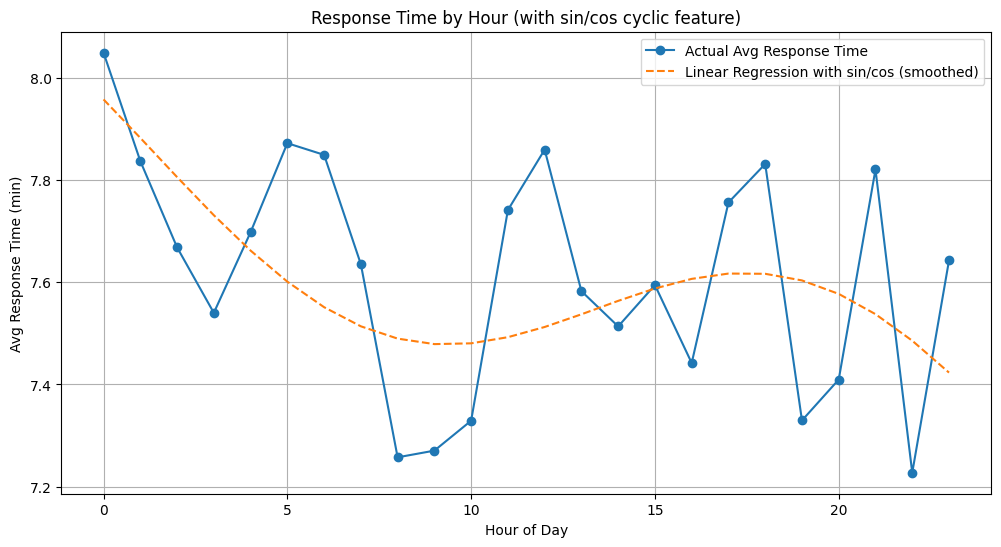

In [14]:
# 畫每日平均 + 預測曲線（smooth）
hourly_avg = df_clean.groupby('Hour')['ResponseTimeMin'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(hourly_avg['Hour'], hourly_avg['ResponseTimeMin'], label='Actual Avg Response Time', marker='o')

# 用model預測每小時（只用sin/cos + 其他feature=0）
X_plot = pd.DataFrame({
    'sin_time': np.sin(2 * np.pi * np.arange(24)*60 / 1440),
    'cos_time': np.cos(2 * np.pi * np.arange(24)*60 / 1440),
    'Is_TTG_num': 0, 'Hour': np.arange(24)
})
plt.plot(np.arange(24), model.predict(X_plot), label='Linear Regression with sin/cos (smoothed)', linestyle='--')

plt.title('Response Time by Hour (with sin/cos cyclic feature)')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Response Time (min)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
### Time-Series Analysis with Cyclic Feature Engineering

#為咗捕捉每日時間週期性（rush hour pattern），我將「小時」轉化成sin_time同cos_time（cyclic encoding）：

#**Model Performance**
#- Linear Regression (features: sin_time, cos_time, Is_TTG_num, Hour)
#- R² = 0.0014（只解釋0.14% variance）
#- RMSE = 2.71 分鐘

#**Key Coefficients**
#- sin_time: -0.184 → 時間循環對response time有顯著但細微影響
#- Is_TTG_num: +0.121 → TTG區即使控制時間因素，都會令response time平均增加0.12分鐘（p<0.05）
#- 圖表顯示：實際平均response time有明顯高峰（hour 0、5–6、11–13、17–18），但model只捕捉到平滑趨勢

#**Business Insights**
#- 時間本身（time-of-day）對response time影響細，遠低於incident type或call volume等因素。
#- TTG區痛點仍然成立，建議優先target TTG區特定小時（e.g. 傍晚5–7pm）。

#**Limitations & Next Steps**
#- R²低反映數據noise大 + 需要更多features（e.g. incident type dummy、call volume per hour、interaction terms）。
#- 下一步：加入更多feature後re-run model，或改用Random Forest / XGBoost提升R²。

# 改善版：加更多feature + interaction
features = ['sin_time', 'cos_time', 'Is_TTG_num', 'Hour', 'inc_type']
X = pd.get_dummies(df_clean[features], columns=['inc_type'], drop_first=True)

# 加interaction（TTG × sin_time）
X['TTG_sin_inter'] = X['Is_TTG_num'] * X['sin_time']

model_improved = LinearRegression()
model_improved.fit(X, y)

print(f"Improved R²: {r2_score(y, model_improved.predict(X)):.4f}")

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
print(f"Random Forest R²: {r2_score(y, rf.predict(X)):.4f}")

Improved R²: 0.0174
Random Forest R²: 0.1283


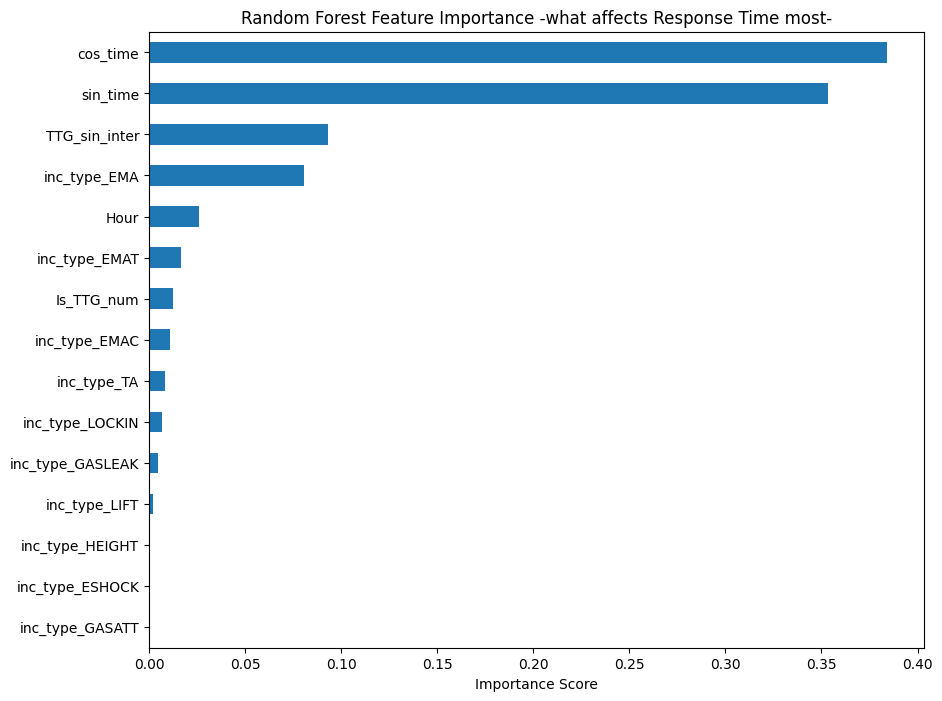

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10,8))
importance.plot(kind='barh')
plt.title('Random Forest Feature Importance -what affects Response Time most-')
plt.xlabel('Importance Score')
plt.show()

In [17]:
import pandas as pd

# 確保有 OnTime 欄
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)

kpi = pd.pivot_table(df_clean, 
                     values=['OnTime', 'ResponseTimeMin'], 
                     index='Hour', 
                     columns='area', 
                     aggfunc={'OnTime': 'mean', 'ResponseTimeMin': ['count', 'mean']})

# 整理欄位名
kpi.columns = ['_'.join(col).strip() for col in kpi.columns.values]
kpi = kpi.rename(columns=lambda x: x.replace('OnTime_mean', 'OnTimeRate')
                                 .replace('ResponseTimeMin_count', 'CallVolume')
                                 .replace('ResponseTimeMin_mean', 'AvgResponse'))

kpi = kpi.reset_index()
print(kpi.head())   # 睇下結果

   Hour  OnTimeRate_CSW  OnTimeRate_LCK  OnTimeRate_MKK  OnTimeRate_SKM  \
0     0        0.943662        0.963415        0.967413        0.931034   
1     1        0.963077        0.956897        0.982456        0.959064   
2     2        0.978182        0.974576        0.990099        0.968354   
3     3        0.981061        0.983333        0.985207        0.990991   
4     4        0.985612        0.964706        0.994083        0.986111   

   OnTimeRate_TST  OnTimeRate_TTG  OnTimeRate_YMT  CallVolume_CSW  \
0        0.940678        0.927083        0.962500             355   
1        0.943878        0.917808        0.985130             325   
2        0.967949        0.982143        0.977860             275   
3        0.993789        0.986111        0.973568             264   
4        0.977612        0.971429        0.994845             278   

   CallVolume_LCK  ...  CallVolume_TST  CallVolume_TTG  CallVolume_YMT  \
0             164  ...             236              96      

In [18]:
import pandas as pd

# 先確認你有邊啲 Area（同 Base 之後會用到）
print("Unique Area:", df_clean['area'].unique())

# 手動 closeness matrix（你根據實際行車時間/距離調整數字）
distance_dict = {
    'CSW': {'CSW': 0, 'LCK': 2, 'MKK': 1, 'SKM': 2, 'TST': 3, 'TTG': 3, 'YMT': 1},
    'LCK': {'CSW': 2, 'LCK': 0, 'MKK': 2, 'SKM': 1, 'TST': 3, 'TTG': 3, 'YMT': 2},
    'MKK': {'CSW': 1, 'LCK': 2, 'MKK': 0, 'SKM': 1, 'TST': 2, 'TTG': 2, 'YMT': 1},
    'SKM': {'CSW': 2, 'LCK': 1, 'MKK': 1, 'SKM': 0, 'TST': 3, 'TTG': 3, 'YMT': 2},
    'TST': {'CSW': 3, 'LCK': 3, 'MKK': 2, 'SKM': 3, 'TST': 0, 'TTG': 1, 'YMT': 2},
    'TTG': {'CSW': 3, 'LCK': 3, 'MKK': 2, 'SKM': 3, 'TST': 1, 'TTG': 0, 'YMT': 2},
    'YMT': {'CSW': 1, 'LCK': 2, 'MKK': 1, 'SKM': 2, 'TST': 2, 'TTG': 2, 'YMT': 0},
}

distance_matrix = pd.DataFrame(distance_dict)
print(distance_matrix)   # 睇下matrix

Unique Area: ['LCK' 'MKK' 'TST' 'TTG' 'YMT' 'CSW' 'SKM']
     CSW  LCK  MKK  SKM  TST  TTG  YMT
CSW    0    2    1    2    3    3    1
LCK    2    0    2    1    3    3    2
MKK    1    2    0    1    2    2    1
SKM    2    1    1    0    3    3    2
TST    3    3    2    3    0    1    2
TTG    3    3    2    3    1    0    2
YMT    1    2    1    2    2    2    0


In [19]:
# 1. 移除尾數（MKK0 → MKK, MON0 → MON）
df_clean['Base'] = df_clean['dep_frm'].str.replace(r'\d+$', '', regex=True).str.strip()

# 2. 如果有兩個 code 代表同一個 base（e.g. MKK 同 MON 都係 Mong Kok）
base_mapping = {
    'MKK': 'MKK',   # Mong Kok
    'MON': 'MKK',   
    'CSW': 'CSW',
    'CHE': 'CSW',
    'LCK': 'LCK',
    'LAI': 'LCK',
    'YAU': 'YMT',
    'YMT': 'YMT',
    'LCK': 'LCK',
    'SKM': 'SKM',
    'TST': 'TST',
    'TTG': 'TTG',
    'TTU': 'TTG',
}

df_clean['Base'] = df_clean['Base'].map(base_mapping).fillna(df_clean['Base'])

print("Final Base:", sorted(df_clean['Base'].unique()))
# 1. 移除尾數（MKK0 → MKK, MON0 → MON）
df_clean['Base'] = df_clean['dep_frm'].str.replace(r'\d+$', '', regex=True).str.strip()

# 2. 如果有兩個 code 代表同一個 base（e.g. MKK 同 MON 都係 Mong Kok）
base_mapping = {
    'MKK': 'MKK',   # Mong Kok
    'MON': 'MKK',   
    'CSW': 'CSW',
    'CHE': 'CSW',
    'LCK': 'LCK',
    'LAI': 'LCK',
    'YAU': 'YMT',
    'YMT': 'YMT',
    'LCK': 'LCK',
    'SKM': 'SKM',
    'TST': 'TST',
    'TTG': 'TTG',
    'TTU': 'TTG',
}

df_clean['Base'] = df_clean['Base'].map(base_mapping).fillna(df_clean['Base'])

print("Final Base:", sorted(df_clean['Base'].unique()))


Final Base: ['CEN', 'CSW', 'CSW7A', 'HHM', 'HOM', 'KBY', 'KCG', 'KCW', 'KLT', 'KTK', 'KTN', 'KWA', 'KWN', 'LAT', 'LCK', 'LCK7A', 'LCK8B', 'LEI', 'LKG', 'LMS', 'MAT', 'MKK', 'MOR', 'MOU', 'MTC', 'NGA', 'PAK', 'SHA', 'SKM', 'SLE', 'SLY', 'STG', 'STN', 'SWN', 'TIN', 'TLW', 'TSI', 'TSM', 'TST', 'TSU', 'TTG', 'TWN', 'TYI', 'TYS', 'WAN', 'WON', 'WTS', 'YMT']
Final Base: ['CEN', 'CSW', 'CSW7A', 'HHM', 'HOM', 'KBY', 'KCG', 'KCW', 'KLT', 'KTK', 'KTN', 'KWA', 'KWN', 'LAT', 'LCK', 'LCK7A', 'LCK8B', 'LEI', 'LKG', 'LMS', 'MAT', 'MKK', 'MOR', 'MOU', 'MTC', 'NGA', 'PAK', 'SHA', 'SKM', 'SLE', 'SLY', 'STG', 'STN', 'SWN', 'TIN', 'TLW', 'TSI', 'TSM', 'TST', 'TSU', 'TTG', 'TWN', 'TYI', 'TYS', 'WAN', 'WON', 'WTS', 'YMT']


In [20]:
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)

# Demand KPI (按 incident Area)
demand_kpi = pd.pivot_table(df_clean, 
                            values='OnTime', 
                            index='Hour', 
                            columns='area', 
                            aggfunc='mean').reset_index()
demand_kpi = demand_kpi.melt(id_vars='Hour', var_name='area', value_name='OnTimeRate')

# Supply KPI (按 departure Base)
supply_kpi = pd.pivot_table(df_clean, 
                            values='OnTime', 
                            index='Hour', 
                            columns='Base', 
                            aggfunc='mean').reset_index()
supply_kpi = supply_kpi.melt(id_vars='Hour', var_name='Base', value_name='OnTimeRate')

In [21]:
# ======================
# 6. 科學 Reallocation Pairing
# ======================
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)

# Demand KPI (按 incident Area)
demand_kpi = pd.pivot_table(df_clean, 
                            values='OnTime', 
                            index='Hour', 
                            columns='area', 
                            aggfunc='mean').reset_index()
demand_kpi = demand_kpi.melt(id_vars='Hour', var_name='area', value_name='OnTimeRate')

# Supply KPI (按 departure Base)
supply_kpi = pd.pivot_table(df_clean, 
                            values='OnTime', 
                            index='Hour', 
                            columns='Base', 
                            aggfunc='mean').reset_index()
supply_kpi = supply_kpi.melt(id_vars='Hour', var_name='Base', value_name='OnTimeRate')


target_hours = [12, 13, 17, 18, 19]

results = []
for hour in target_hours:
    # Demand (Area)
    hour_demand = demand_kpi[demand_kpi['Hour'] == hour]
    if hour_demand.empty:
        continue
    recipient_row = hour_demand.loc[hour_demand['OnTimeRate'].idxmin()]
    recipient = recipient_row['area']
    need_score = 1 - recipient_row['OnTimeRate']
    
    # Supply (Base)
    hour_supply = supply_kpi[supply_kpi['Hour'] == hour]
    if hour_supply.empty:
        continue
    donor_row = hour_supply.loc[hour_supply['OnTimeRate'].idxmax()]
    donor = donor_row['Base']
    slack_score = donor_row['OnTimeRate']
    
    # Distance check
    try:
        dist_score = distance_matrix.loc[donor, recipient]
    except KeyError:
        dist_score = 99   # 未知 = 太遠
    
    if dist_score <= 2:   # 可接受距離
        results.append({
            'Hour': hour,
            'Recipient_Area': recipient,
            'Donor_Base': donor,
            'Distance_Score': dist_score,
            'NeedScore': round(need_score, 4),
            'SlackScore': round(slack_score, 4)
        })

realloc_table = pd.DataFrame(results)
print("\n=== Final Decision ===")
print(realloc_table)


=== Final Decision ===
Empty DataFrame
Columns: []
Index: []


In [22]:
# ======================
# Debug + Reallocation Loop（即刻跑呢個！）
# ======================
target_hours = [12, 13, 17, 18, 19]

results = []
for hour in target_hours:
    print(f"\n--- Hour {hour} ---")
    
    # Demand
    hour_demand = demand_kpi[demand_kpi['Hour'] == hour]
    if hour_demand.empty:
        print("  Demand 冇數據")
        continue
    recipient_row = hour_demand.loc[hour_demand['OnTimeRate'].idxmin()]
    recipient = recipient_row['area']
    need_score = 1 - recipient_row['OnTimeRate']
    print(f"  Recipient (最差): {recipient} (OnTimeRate = {recipient_row['OnTimeRate']:.4f})")
    
    # Supply
    hour_supply = supply_kpi[supply_kpi['Hour'] == hour]
    if hour_supply.empty:
        print("  Supply 冇數據")
        continue
    donor_row = hour_supply.loc[hour_supply['OnTimeRate'].idxmax()]
    donor = donor_row['Base']
    slack_score = donor_row['OnTimeRate']
    print(f"  Donor Base (最好): {donor} (OnTimeRate = {slack_score:.4f})")
    
    # Distance
    try:
        dist_score = distance_matrix.loc[donor, recipient]
    except KeyError:
        dist_score = 99
    print(f"  Distance Score: {dist_score}")
    
    # === 暫時放寬條件睇下全部 pair ===
    if dist_score <= 3:   # 先改成 <=3 睇下有冇 pair
        results.append({
            'Hour': hour,
            'Recipient_Area': recipient,
            'Donor_Base': donor,
            'Distance_Score': dist_score,
            'NeedScore': round(need_score, 4),
            'SlackScore': round(slack_score, 4)
        })
    else:
        print(f"  ❌ 距離太遠 (dist={dist_score})，唔建議調動")

realloc_table = pd.DataFrame(results)
print("\n=== 最科學調動建議（距離 <=3） ===")
print(realloc_table)




--- Hour 12 ---
  Recipient (最差): TST (OnTimeRate = 0.8876)
  Donor Base (最好): KBY (OnTimeRate = 1.0000)
  Distance Score: 99
  ❌ 距離太遠 (dist=99)，唔建議調動

--- Hour 13 ---
  Recipient (最差): TTG (OnTimeRate = 0.9209)
  Donor Base (最好): KWA (OnTimeRate = 1.0000)
  Distance Score: 99
  ❌ 距離太遠 (dist=99)，唔建議調動

--- Hour 17 ---
  Recipient (最差): TST (OnTimeRate = 0.9269)
  Donor Base (最好): CSW7A (OnTimeRate = 1.0000)
  Distance Score: 99
  ❌ 距離太遠 (dist=99)，唔建議調動

--- Hour 18 ---
  Recipient (最差): TST (OnTimeRate = 0.8750)
  Donor Base (最好): CSW7A (OnTimeRate = 1.0000)
  Distance Score: 99
  ❌ 距離太遠 (dist=99)，唔建議調動

--- Hour 19 ---
  Recipient (最差): TST (OnTimeRate = 0.9274)
  Donor Base (最好): CSW7A (OnTimeRate = 1.0000)
  Distance Score: 99
  ❌ 距離太遠 (dist=99)，唔建議調動

=== 最科學調動建議（距離 <=3） ===
Empty DataFrame
Columns: []
Index: []


In [23]:
import pandas as pd

# 1. 確保 OnTime 欄存在
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)

# 2. 只用 Area 做 KPI（Demand + Supply 都用同一個）
area_kpi = pd.pivot_table(
    df_clean,
    values='OnTime',
    index='Hour',
    columns='area',
    aggfunc='mean'
).reset_index()

area_kpi = area_kpi.melt(
    id_vars='Hour',
    var_name='area',
    value_name='OnTimeRate'
)

print("Area KPI 建立完成！")
print(area_kpi.head())

# 3. Distance Matrix（已經 cover 你主要 Area）
distance_dict = {
    'CSW': {'CSW':0, 'LCK':3, 'MKK':1, 'SKM':2, 'TST':3, 'TTG':3, 'YMT':1},
    'LCK': {'CSW':2, 'LCK':0, 'MKK':2, 'SKM':1, 'TST':4, 'TTG':4, 'YMT':2},
    'MKK': {'CSW':1, 'LCK':2, 'MKK':0, 'SKM':1, 'TST':3, 'TTG':3, 'YMT':1},
    'SKM': {'CSW':2, 'LCK':1, 'MKK':1, 'SKM':0, 'TST':3, 'TTG':3, 'YMT':2},
    'TST': {'CSW':3, 'LCK':4, 'MKK':2, 'SKM':3, 'TST':0, 'TTG':1, 'YMT':1},
    'TTG': {'CSW':3, 'LCK':3, 'MKK':2, 'SKM':3, 'TST':1, 'TTG':0, 'YMT':1},
    'YMT': {'CSW':1, 'LCK':2, 'MKK':1, 'SKM':2, 'TST':1, 'TTG':1, 'YMT':0},
}
distance_matrix = pd.DataFrame(distance_dict)

# 4. 科學 Reallocation（只用 Area）
target_hours = [12, 13, 17, 18, 19]

results = []
for hour in target_hours:
    print(f"\n--- Hour {hour} ---")
    
    hour_data = area_kpi[area_kpi['Hour'] == hour]
    if hour_data.empty:
        print("  冇數據")
        continue
    
    # Recipient = OnTimeRate 最低（最需要）
    recipient_row = hour_data.loc[hour_data['OnTimeRate'].idxmin()]
    recipient = recipient_row['area']
    need_score = 1 - recipient_row['OnTimeRate']
    print(f"  Recipient (最差): {recipient} (OnTime = {recipient_row['OnTimeRate']:.4f})")
    
    # Donor = OnTimeRate 最高（最有 slack），但唔可以係自己
    donor_data = hour_data[hour_data['area'] != recipient]
    if donor_data.empty:
        print("  冇其他 Area")
        continue
    donor_row = donor_data.loc[donor_data['OnTimeRate'].idxmax()]
    donor = donor_row['area']
    slack_score = donor_row['OnTimeRate']
    print(f"  Donor (最好): {donor} (OnTime = {slack_score:.4f})")
    
    # Distance check
    try:
        dist_score = distance_matrix.loc[donor, recipient]
    except KeyError:
        dist_score = 99
    print(f"  Distance Score: {dist_score}")
    
    if dist_score <= 3:      # 你可以改成 <=3 先睇多啲 pair
        results.append({
            'Hour': hour,
            'Recipient_Area': recipient,
            'Donor_Area': donor,
            'Distance_Score': dist_score,
            'NeedScore': round(need_score, 4),
            'SlackScore': round(slack_score, 4)
        })
    else:
        print(f"  ❌ 距離太遠 (dist={dist_score})，唔建議")

realloc_table = pd.DataFrame(results)
print("\n=== 最科學調動建議（只用 Area） ===")
print(realloc_table)

Area KPI 建立完成！
   Hour area  OnTimeRate
0     0  CSW    0.943662
1     1  CSW    0.963077
2     2  CSW    0.978182
3     3  CSW    0.981061
4     4  CSW    0.985612

--- Hour 12 ---
  Recipient (最差): TST (OnTime = 0.8876)
  Donor (最好): CSW (OnTime = 0.9741)
  Distance Score: 3

--- Hour 13 ---
  Recipient (最差): TTG (OnTime = 0.9209)
  Donor (最好): CSW (OnTime = 0.9860)
  Distance Score: 3

--- Hour 17 ---
  Recipient (最差): TST (OnTime = 0.9269)
  Donor (最好): LCK (OnTime = 0.9883)
  Distance Score: 4
  ❌ 距離太遠 (dist=4)，唔建議

--- Hour 18 ---
  Recipient (最差): TST (OnTime = 0.8750)
  Donor (最好): LCK (OnTime = 0.9758)
  Distance Score: 4
  ❌ 距離太遠 (dist=4)，唔建議

--- Hour 19 ---
  Recipient (最差): TST (OnTime = 0.9274)
  Donor (最好): CSW (OnTime = 0.9825)
  Distance Score: 3

=== 最科學調動建議（只用 Area） ===
   Hour Recipient_Area Donor_Area  Distance_Score  NeedScore  SlackScore
0    12            TST        CSW               3     0.1124      0.9741
1    13            TTG        CSW               3     

In [24]:
target_hours = [12, 13, 17, 18, 19]

results = []
for hour in target_hours:
    print(f"\n--- Hour {hour} ---")
    
    hour_data = area_kpi[area_kpi['Hour'] == hour]
    if hour_data.empty:
        continue
    
    # Recipient (最需要)
    recipient_row = hour_data.loc[hour_data['OnTimeRate'].idxmin()]
    recipient = recipient_row['area']
    need_score = 1 - recipient_row['OnTimeRate']
    print(f"  Recipient: {recipient} (OnTime = {recipient_row['OnTimeRate']:.4f})")
    
    # 考慮所有可能 donor（包括 YMT）
    hour_data_no_recip = hour_data[hour_data['area'] != recipient]
    
    donor_candidates = []
    for _, donor_row in hour_data_no_recip.iterrows():
        donor = donor_row['area']
        donor_ontime = donor_row['OnTimeRate']
        
        try:
            dist_score = distance_matrix.loc[donor, recipient]
        except KeyError:
            dist_score = 99
        
        if dist_score > 3:
            continue   # 太遠就跳過
        
        # 計算綜合 Priority Score
        proximity = 3 - dist_score
        priority_score = need_score * proximity / donor_ontime if donor_ontime > 0 else 0
        
        donor_candidates.append({
            'Donor': donor,
            'Donor_OnTime': round(donor_ontime, 4),
            'Distance': dist_score,
            'Priority_Score': round(priority_score, 4)
        })
    
    if not donor_candidates:
        print("  冇合適 donor")
        continue
    
    # 排序 Priority Score 最高嘅排前面
    candidates_df = pd.DataFrame(donor_candidates)
    candidates_df = candidates_df.sort_values('Priority_Score', ascending=False)
    
    print("  Top Donor Candidates:")
    print(candidates_df.head(5))
    
    # 取最好嘅一個
    best = candidates_df.iloc[0]
    results.append({
        'Hour': hour,
        'Recipient_Area': recipient,
        'Best_Donor': best['Donor'],
        'Distance_Score': best['Distance'],
        'Priority_Score': best['Priority_Score'],
        'NeedScore': round(need_score, 4),
        'Donor_OnTime': best['Donor_OnTime']
    })

final_realloc = pd.DataFrame(results)
print("\n=== 綜合考慮距離後嘅最佳調動建議 ===")
print(final_realloc)


--- Hour 12 ---
  Recipient: TST (OnTime = 0.8876)
  Top Donor Candidates:
  Donor  Donor_OnTime  Distance  Priority_Score
3   TTG        0.8882         1          0.2531
4   YMT        0.9515         1          0.2362
1   MKK        0.9713         2          0.1157
0   CSW        0.9741         3          0.0000
2   SKM        0.9419         3          0.0000

--- Hour 13 ---
  Recipient: TTG (OnTime = 0.9209)
  Top Donor Candidates:
  Donor  Donor_OnTime  Distance  Priority_Score
4   TST        0.9258         1          0.1709
5   YMT        0.9614         1          0.1645
2   MKK        0.9823         2          0.0805
0   CSW        0.9860         3          0.0000
1   LCK        0.9840         3          0.0000

--- Hour 17 ---
  Recipient: TST (OnTime = 0.9269)
  Top Donor Candidates:
  Donor  Donor_OnTime  Distance  Priority_Score
4   YMT        0.9501         1          0.1538
3   TTG        0.9730         1          0.1502
1   MKK        0.9561         2          0.0764
0   

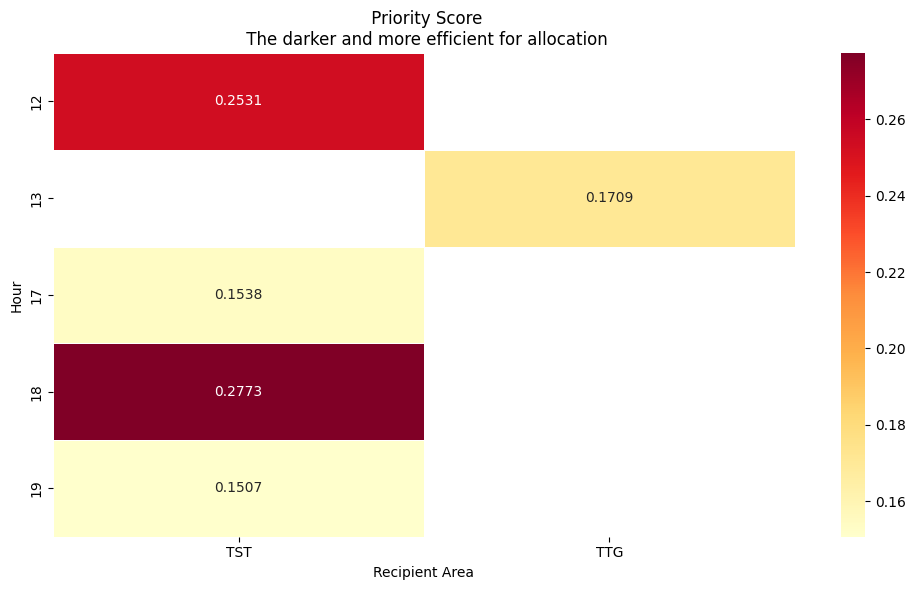

 Hour Recipient_Area Best_Donor  Distance_Score  Priority_Score
   12            TST        TTG               1          0.2531
   13            TTG        TST               1          0.1709
   17            TST        YMT               1          0.1538
   18            TST        TTG               1          0.2773
   19            TST        YMT               1          0.1507


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 用你之前嘅 final_realloc DataFrame
pivot = final_realloc.pivot(index='Hour', columns='Recipient_Area', values='Priority_Score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.4f', linewidths=0.5)
plt.title(' Priority Score\n The darker and more efficient for allocation')
plt.ylabel('Hour')
plt.xlabel('Recipient Area')
plt.tight_layout()
plt.show()

print(final_realloc[['Hour', 'Recipient_Area', 'Best_Donor', 'Distance_Score', 'Priority_Score']].to_string(index=False))

原始符合條件個案數量: 68,058
清理後用於建模個案數量: 67,875

=== CMC 送院時間 Regression Model ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             13.0337      0.042    310.792      0.000      12.952      13.116
IsRushHour[T.True]     0.0774      0.073      1.057      0.290      -0.066       0.221
sin_time              -0.7285      0.051    -14.366      0.000      -0.828      -0.629
cos_time              -0.5220      0.048    -10.790      0.000      -0.617      -0.427
Rush hour 平均送院時間比非rush hour 長: 0.12 分鐘

=== KWH 送院時間 Regression Model ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             11.7114      0.038    308.299      0.000      11.637      11.786
IsRushHour[T.True]    -0.0330      0.067     -0.492      0.623      -

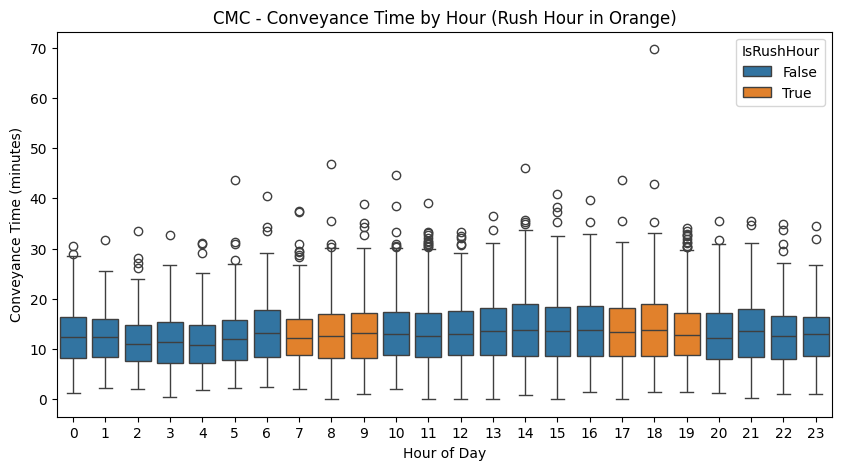

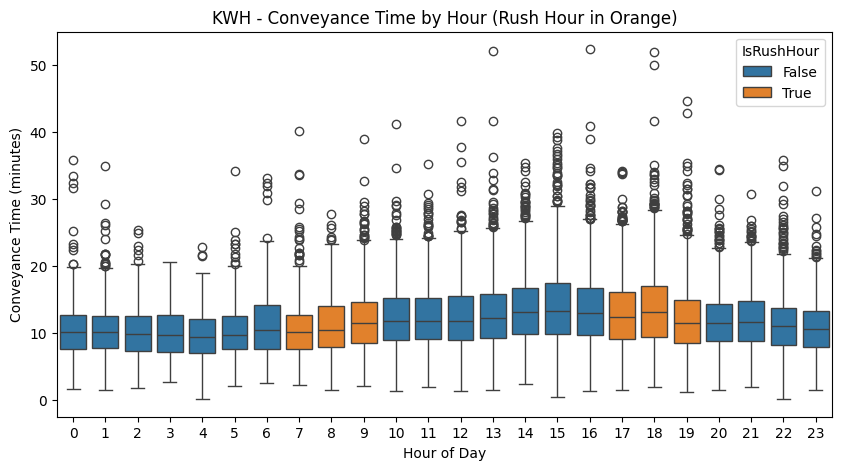

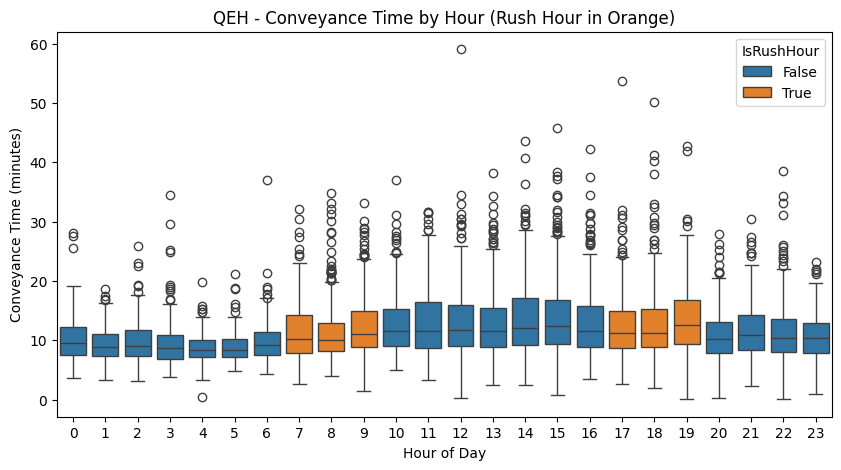

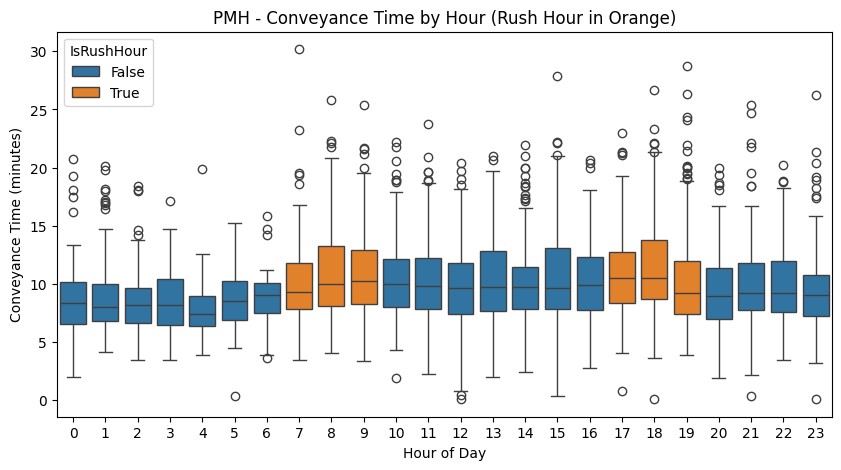

In [26]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. 數據過濾 + 清理
# ======================
hospitals = ['CMC', 'KWH', 'QEH', 'PMH']
inc_types = ['EMA', 'EMAC', 'EMAT']

df_hosp = df_clean[
    df_clean['dest'].isin(hospitals) & 
    df_clean['inc_type'].isin(inc_types)
].copy()

print(f"原始符合條件個案數量: {len(df_hosp):,}")

# 轉時間格式
df_hosp['e99_time'] = pd.to_datetime(df_hosp['e99_time'], errors='coerce')
df_hosp['arh_time'] = pd.to_datetime(df_hosp['arh_time'], errors='coerce')

# 計算送院時間（分鐘）
df_hosp['ConveyanceMin'] = (df_hosp['arh_time'] - df_hosp['e99_time']).dt.total_seconds() / 60

# 排除無效 / 極端值
df_model = df_hosp[
    (df_hosp['ConveyanceMin'] > 0) & 
    (df_hosp['ConveyanceMin'] <= 120) &   # >2小時 = 極端
    df_hosp['ConveyanceMin'].notna()
].copy()

print(f"清理後用於建模個案數量: {len(df_model):,}")

# ======================
# 2. 新增特徵
# ======================
df_model['Hour'] = df_model['e99_time'].dt.hour
df_model['IsRushHour'] = ((df_model['Hour'] >= 7) & (df_model['Hour'] <= 9)) | \
                         ((df_model['Hour'] >= 17) & (df_model['Hour'] <= 19))

# sin/cos cyclic feature（捕捉時間週期）
df_model['StartMinOfDay'] = df_model['e99_time'].dt.hour * 60 + df_model['e99_time'].dt.minute
df_model['sin_time'] = np.sin(2 * np.pi * df_model['StartMinOfDay'] / 1440)
df_model['cos_time'] = np.cos(2 * np.pi * df_model['StartMinOfDay'] / 1440)

# ======================
# 3. 每個醫院獨立跑 OLS Regression
# ======================
model_results = {}

for hosp in hospitals:
    df_h = df_model[df_model['dest'] == hosp].copy()
    
    if len(df_h) < 50:   # 數據太少就跳過
        print(f"\n{hosp} 數據不足 ({len(df_h)}宗)，跳過")
        continue
    
    # Regression model: ConveyanceMin ~ IsRushHour + Hour + sin_time + cos_time
    formula = 'ConveyanceMin ~ IsRushHour + sin_time + cos_time'
    model = smf.ols(formula, data=df_h).fit()
    
    model_results[hosp] = model
    
    print(f"\n=== {hosp} 送院時間 Regression Model ===")
    print(model.summary().tables[1])   # 印係數表
    
    # 簡單相關係數
    corr_rush = df_h[df_h['IsRushHour']]['ConveyanceMin'].mean() - df_h[~df_h['IsRushHour']]['ConveyanceMin'].mean()
    print(f"Rush hour 平均送院時間比非rush hour 長: {corr_rush:.2f} 分鐘")

# ======================
# 4. 可視化（每個醫院一張圖，可放presentation）
# ======================
for hosp in model_results.keys():
    df_h = df_model[df_model['dest'] == hosp]
    plt.figure(figsize=(10,5))
    sns.boxplot(x='Hour', y='ConveyanceMin', hue='IsRushHour', data=df_h)
    plt.title(f'{hosp} - Conveyance Time by Hour (Rush Hour in Orange)')
    plt.ylabel('Conveyance Time (minutes)')
    plt.xlabel('Hour of Day')
    plt.show()

/tmp/ipykernel_16/3853371267.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  overall_pivot = pd.pivot_table(df_clean,


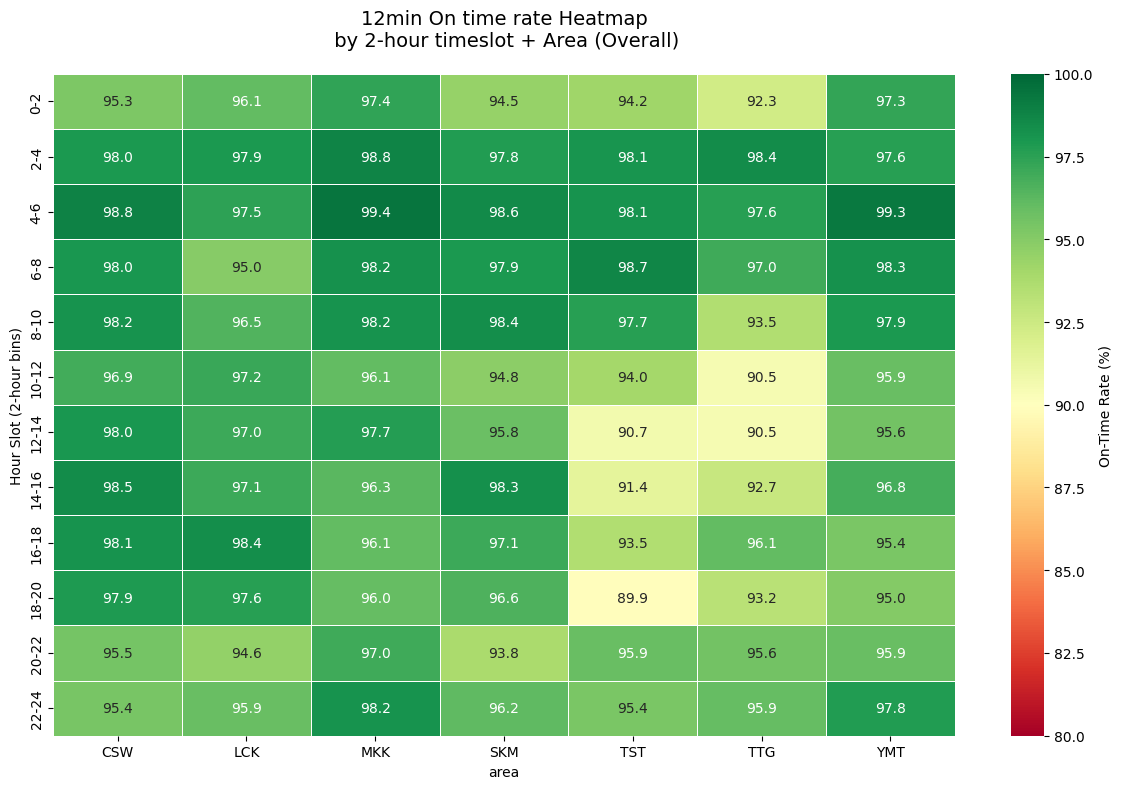

/tmp/ipykernel_16/3853371267.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_slot = df_clean.groupby('HourSlot')['OnTime'].mean() * 100
/tmp/ipykernel_16/3853371267.py:58: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3853371267.py:58: UserWarning: Glyph 39636 (\N{CJK UNIFIED IDEOGRAPH-9AD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3853371267.py:58: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3853371267.py:58: UserWarning: Glyph 37912 (\N{CJK UNIFIED IDEOGRAPH-9418}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3853371267.py:58: UserWarning: Glyph 36948 (\

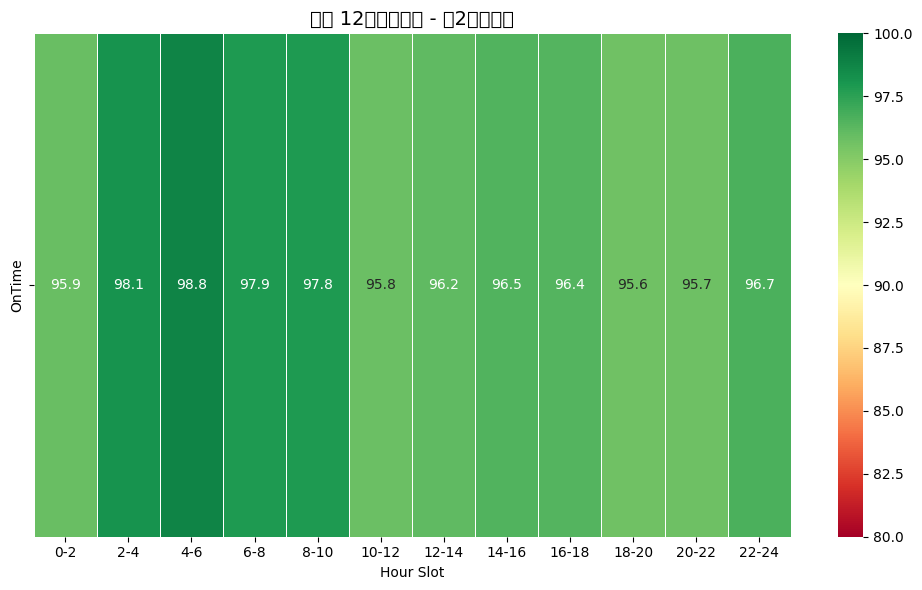

Overall 12min On time rate:
HourSlot
0-2      95.9
2-4      98.1
4-6      98.8
6-8      97.9
8-10     97.8
10-12    95.8
12-14    96.2
14-16    96.5
16-18    96.4
18-20    95.6
20-22    95.7
22-24    96.7
Name: OnTime, dtype: float64


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 確保有 OnTime 欄
df_clean['OnTime'] = (df_clean['ResponseTimeMin'] <= 12).astype(int)

# ======================
# 1. 建立 2小時一個時段 (Bin)
# ======================
df_clean['HourSlot'] = pd.cut(df_clean['Hour'], 
                              bins=[0,2,4,6,8,10,12,14,16,18,20,22,24],
                              labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-12',
                                      '12-14', '14-16', '16-18', '18-20', '20-22', '22-24'],
                              right=False)

# ======================
# 2. Overall Heatmap (全九龍西)
# ======================
overall_pivot = pd.pivot_table(df_clean, 
                               values='OnTime',
                               index='HourSlot',
                               columns='area',
                               aggfunc='mean') * 100   # 轉成百分比

plt.figure(figsize=(12, 8))
sns.heatmap(overall_pivot, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn',      # 紅→黃→綠
            vmin=80, vmax=100,  # 顏色範圍
            linewidths=0.5,
            cbar_kws={'label': 'On-Time Rate (%)'})

plt.title('12min On time rate Heatmap\n by 2-hour timeslot + Area (Overall)', fontsize=14, pad=20)
plt.ylabel('Hour Slot (2-hour bins)')
plt.xlabel('area')
plt.tight_layout()
plt.show()

# ======================
# 3. 整體 (不分Area) 的 2小時時段 Heatmap / Bar
# ======================
overall_slot = df_clean.groupby('HourSlot')['OnTime'].mean() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(overall_slot.to_frame().T, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn', 
            vmin=80, vmax=100,
            linewidths=0.5)

plt.title('整體 12分鐘達標率 - 按2小時時段', fontsize=14)
plt.ylabel('')
plt.xlabel('Hour Slot')
plt.tight_layout()
plt.show()

print("Overall 12min On time rate:")
print(overall_slot.round(1))

No. of cases after cleaning: 68,153
no. of cases suiltable for heatmap: 67,968


/tmp/ipykernel_16/3230003703.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


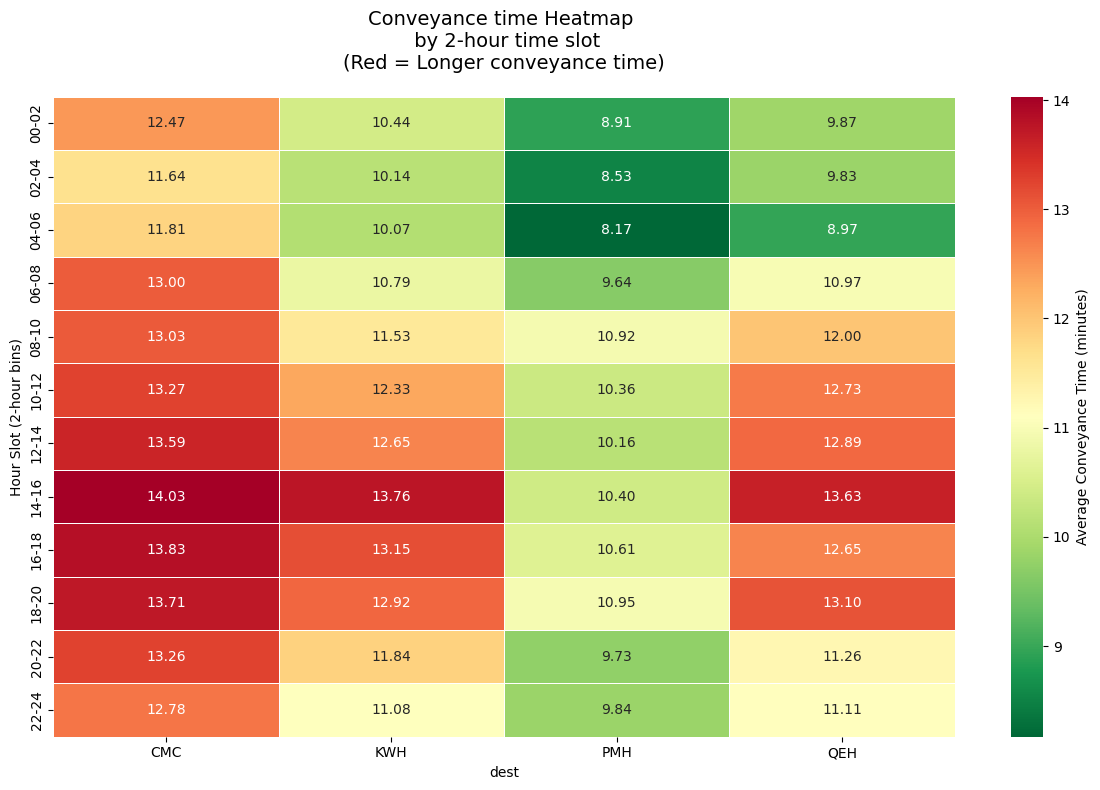

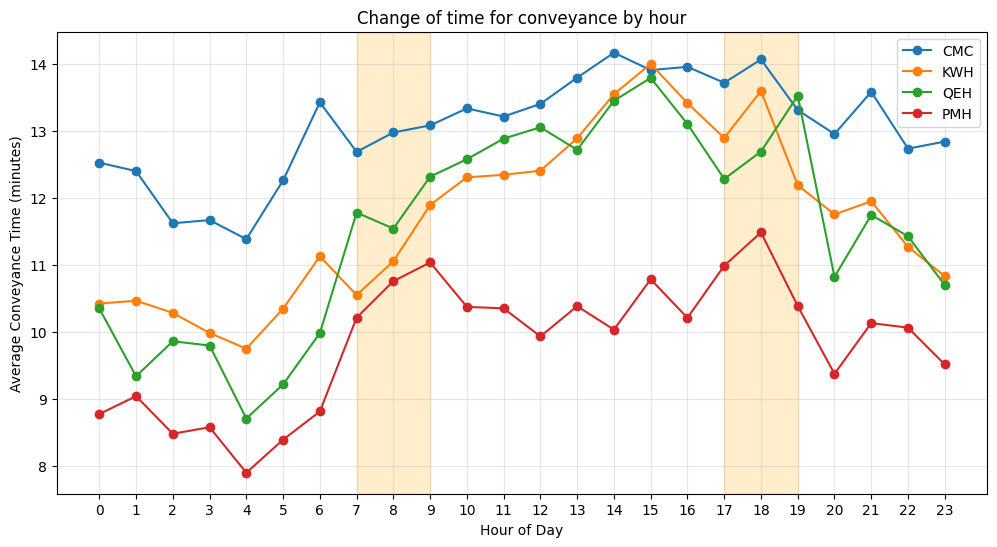

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. data cleaning
# ======================
hospitals = ['CMC', 'KWH', 'QEH', 'PMH']
inc_types = ['EMA', 'EMAC', 'EMAT', 'EMAVIO1', 'EMAVIO2', 'TA']

df_hosp = df_clean[
    (df_clean['dest'].isin(hospitals)) & 
    (df_clean['inc_type'].isin(inc_types))
].copy()

print(f"No. of cases after cleaning: {len(df_hosp):,}")

# change time context
df_hosp['e99_time'] = pd.to_datetime(df_hosp['e99_time'], errors='coerce')
df_hosp['arh_time'] = pd.to_datetime(df_hosp['arh_time'], errors='coerce')

# calculate
df_hosp['ConveyanceMin'] = (df_hosp['arh_time'] - df_hosp['e99_time']).dt.total_seconds() / 60

# ignore non-effective values
df_model = df_hosp[
    (df_hosp['ConveyanceMin'] > 0) & 
    (df_hosp['ConveyanceMin'] <= 60) & 
    df_hosp['ConveyanceMin'].notna()
].copy()

print(f"no. of cases suiltable for heatmap: {len(df_model):,}")

# ======================
# 2. develop 2-HourSlot
# ======================
df_model['Hour'] = df_model['e99_time'].dt.hour

df_model['HourSlot'] = pd.cut(df_model['Hour'], 
                              bins=[0,2,4,6,8,10,12,14,16,18,20,22,24],
                              labels=['00-02', '02-04', '04-06', '06-08', '08-10', '10-12',
                                      '12-14', '14-16', '16-18', '18-20', '20-22', '22-24'],
                              right=False)

# ======================
# 3. 計算平均送院時間 Heatmap
# ======================
heatmap_data = pd.pivot_table(
    df_model,
    values='ConveyanceMin',
    index='HourSlot',
    columns='dest',
    aggfunc='mean'
).round(2)

# ======================
# 4. 畫 Heatmap
# ======================
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn_r',      
            linewidths=0.5,
            cbar_kws={'label': 'Average Conveyance Time (minutes)'})

plt.title('Conveyance time Heatmap \n by 2-hour time slot\n(Red = Longer conveyance time)', 
          fontsize=14, pad=20)
plt.ylabel('Hour Slot (2-hour bins)')
plt.xlabel('dest')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
for hosp in hospitals:
    hosp_data = df_model[df_model['dest'] == hosp]
    hourly_avg = hosp_data.groupby('Hour')['ConveyanceMin'].mean()
    plt.plot(hourly_avg.index, hourly_avg.values, marker='o', label=hosp)

plt.title('Change of time for conveyance by hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Conveyance Time (minutes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.axvspan(7, 9, alpha=0.2, color='orange', label='Morning Rush')
plt.axvspan(17, 19, alpha=0.2, color='orange', label='Evening Rush')
plt.show()